# Binary example with `c4fairness`

`c4fairness` clusters the test set on the features, letting the data's own geometry define the subgroups, and then reports the model's error per cluster alongside which protected groups each cluster concentrates. Pockets of high error that a per-attribute average washes out show up as their own clusters, each with a significance test attached.

For binary classification the error is either a plain 0/1 mistake column or one of the confusion-matrix rates. Here it is the false-positive rate: among defendants who did not re-offend, how often the model said they would. FPR is conditional, defined only over the actual negatives, so rows outside its denominator are excluded rather than counted as correct.

This notebook runs the full audit with the Python API on a recidivism classifier, the same audit the CLI `--experiment` mode sweeps automatically over feature-group combinations.

Data: `datasets/compas_audit.csv` (5050 defendants, each row carrying the model's `predicted_class`). Sensitive attributes cover two kinds: binary `sex` and multi-categorical `race` (6 categories), plus numeric `age`.

In [1]:
import numpy as np
import pandas as pd
from c4fairness.result_viz import plot_cluster_recap_heatmap
from IPython.display import Image

raw = pd.read_csv("datasets/compas_audit.csv")
df = raw[["age", "priors_count", "sex", "race", "true_class", "predicted_class"]].copy()
print(df.shape)
df.head()

(5050, 6)


,age,priors_count,sex,race,true_class,predicted_class
0,29,11,Female,Caucasian,1,1
1,48,5,Male,African-American,1,0
2,52,7,Male,African-American,1,0
3,32,0,Male,Other,0,0
4,30,3,Female,Caucasian,0,1


## 1. The columns

`true_class` and `predicted_class` are the ground truth and the model's 0/1 output, where 1 means predicted to re-offend. The error we audit is derived from those two. `age` and `priors_count` are the features we cluster on (`regular`). `sex`, `race` and `age` are the protected attributes we check each cluster against (`sensitive`).

`age` is both a clustering feature and a sensitive attribute. The two roles are independent.

In [2]:
# The confusion matrix the whole audit rests on (positive class = 1 = "will re-offend").
tp = ((df.true_class == 1) & (df.predicted_class == 1)).sum()
fp = ((df.true_class == 0) & (df.predicted_class == 1)).sum()
fn = ((df.true_class == 1) & (df.predicted_class == 0)).sum()
tn = ((df.true_class == 0) & (df.predicted_class == 0)).sum()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"overall FPR = FP/(FP+TN) = {fp/(fp+tn):.3f}")

TP=1263  FP=935  FN=1013  TN=1839
overall FPR = FP/(FP+TN) = 0.337


## 2. The aggregate view

FPR is conditional: it is defined only over the actual non-re-offenders (`true_class == 0`). Below is the per-race FPR, the standard group-fairness number, one value per group with no structure inside it. Clustering refines this.

In [3]:
neg = df[df.true_class == 0]           # FPR's denominator = actual negatives
per_race_fpr = (neg.assign(fp=(neg.predicted_class == 1))
                   .groupby("race")["fp"].mean().sort_values(ascending=False))
per_race_fpr.round(3)

race
African-American    0.399
Caucasian           0.326
Hispanic            0.215
Native American     0.200
Other               0.167
Asian               0.000
Name: fp, dtype: float64

## 3. Encode and cluster

`encode_categoricals` one-hot encodes the string columns (`sex`, `race`) for the Euclidean distance and returns `multiclass_dummies` (mcd), the map from `race` to its dummy columns, which we use later to rebuild a readable `race` column for the tables. The 0/1 dummies are kept out of `StandardScaler`, since scaling binary indicators distorts distances.

In [4]:
from c4fairness.preprocessing import encode_categoricals
from c4fairness.clustering import cluster

sensitive = ["sex", "race", "age"]
col_lists = {"regular": ["age", "priors_count"], "sensitive": sensitive, "proxy": [], "special": []}
orig_sensitive = list(sensitive)

dfe, cl, cat_names, mcd, ohe = encode_categoricals(
    df.copy(), col_lists, [], "kmeans", distance="euclidean"
)
print("race ->", mcd["race"])           # the one-hot columns race was expanded into
clustering_cols = cl["regular"] + cl["sensitive"]
clustering_cols

race -> ['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']


['age',
 'priors_count',
 'sex_Male',
 'race_African-American',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Native American',
 'race_Other',
 'age']

In [5]:
res = cluster(dfe[clustering_cols], algorithm="kmeans", distance="euclidean",
              n_clusters=4, random_state=42)
print(f"k = {res.n_clusters}   silhouette = {res.silhouette:.3f}")
print("cluster sizes:", res.cluster_sizes)

k = 4   silhouette = 0.406
cluster sizes: {np.int32(0): np.int64(1726), np.int32(1): np.int64(2628), np.int32(2): np.int64(433), np.int32(3): np.int64(263)}


## 4. Define the error

`binary_error_rate_column` turns `true_class` and `predicted_class` into a per-row column whose mean over any set of rows is that set's FPR. Rows outside the rate's denominator, the actual positives, are set to `NaN`, so every downstream metric that averages the column and every 2x2 significance test reads the conditional rate.

In [6]:
from c4fairness.fairness_metrics import binary_error_rate_column

fpr_col = binary_error_rate_column(df["true_class"], df["predicted_class"], "fpr")
print(fpr_col.value_counts(dropna=False))   # 1 = FP, 0 = TN, NaN = actual positive (excluded)
print("mean over non-NaN =", round(fpr_col.mean(), 3), "= overall FPR")

NaN    2276
0.0    1839
1.0     935
Name: count, dtype: int64
mean over non-NaN = 0.337 = overall FPR


## 5. Build the per-cluster recap

`make_recap` produces one row per cluster. Sensitive features are shown in salient form, one readable column per feature with its dominant category, which needs two steps: `build_sensitive_analysis_list` names the columns to analyse, and `apply_salient_reconstruction` rebuilds the readable `race` column in the recap frame. `age` is declared continuous, so it is summarised by its median rather than treated as categories.

In [7]:
from c4fairness.cli import build_sensitive_analysis_list, apply_salient_reconstruction
from c4fairness.experiments import make_recap

analysis = build_sensitive_analysis_list(cl["sensitive"], mcd, orig_sensitive, option="salient")

dfe["fpr"] = fpr_col.values
res_df = dfe.copy()
res_df["clusters"] = res.labels
apply_salient_reconstruction(res_df, mcd, orig_sensitive)   # rebuild readable 'race'

recap = make_recap(res_df, clustering_cols, sensitive_cols=analysis,
                   error_col="fpr", error_type="binary",
                   feature_matrix=res.feature_matrix, continuous_sensitive_cols=["age"])
recap.round(3)

,c,count,proportion,n_error,error_value,error_gap,error_gap_sig,sex_Male_value,sex_Male_gap,sex_Male_gap_sig,age_value,age_gap,age_gap_sig,race_value,race_cat,race_gap,race_gap_cat,race_gap_sig,silh
0,0,1726,0.342,342,0.321,-0.025,0.173,0.776,-0.045,0.000,36.0,6.0,0.000,0.986,Caucasian,0.986,Caucasian,0.0,0.345
1,1,2628,0.520,508,0.398,0.113,0.000,0.820,0.030,0.008,30.0,-5.0,0.000,0.995,African-American,0.995,African-American,0.0,0.403
2,2,433,0.086,57,0.215,-0.135,0.000,0.827,0.023,0.278,33.0,1.0,0.066,1.000,Hispanic,1.000,Hispanic,0.0,0.536
3,3,263,0.052,28,0.167,-0.181,0.000,0.821,0.016,0.571,33.0,1.0,0.157,1.000,Other,1.000,Other,0.0,0.613


## 6. Reading the recap

One row per cluster:

- `error_value`: the cluster's FPR.
- `error_gap`: this cluster's FPR minus the FPR of all other rows, one-vs-all. Positive means worse than the rest.
- `error_gap_sig`: Fisher-exact p-value for that gap. Lower is more significant.
- `race_value` and `race_cat`: the proportion in the dominant race, and which race that is.
- `race_gap_sig`: chi-square p-value for whether race composition differs across clusters.
- `sex_Male_value` and `age_value`: male proportion and median age.

Sort by FPR to find the disparate cluster and see who it holds:

In [8]:
view = recap[["c", "count", "error_value", "error_gap", "error_gap_sig",
              "race_cat", "sex_Male_value", "age_value"]].sort_values("error_value", ascending=False)
view.round(3)

,c,count,error_value,error_gap,error_gap_sig,race_cat,sex_Male_value,age_value
1,1,2628,0.398,0.113,0.000,African-American,0.820,30.0
0,0,1726,0.321,-0.025,0.173,Caucasian,0.776,36.0
2,2,433,0.215,-0.135,0.000,Hispanic,0.827,33.0
3,3,263,0.167,-0.181,0.000,Other,0.821,33.0


The cluster with the highest FPR and a significant `FP Rate gap sig.` is where the model most over-predicts risk; its `race`/`age` columns show which defendants land there. Unlike a per-race average, this pinpoints the intersection of features that the model misclassifies most — but note that the cluster's size matters: a large cluster with a high FPR affects more people than a small one, and a cluster that is most of the data is not a "subgroup" in the usual sense.

In [9]:
worst = int(view.iloc[0]["c"])
inside = res_df[res_df["clusters"] == worst]
print(f"cluster {worst}: n={len(inside)}, FPR={recap.loc[recap.c==worst,'error_value'].iloc[0]:.3f}")
inside["race"].value_counts(normalize=True).round(3)

cluster 1: n=2628, FPR=0.398


race
African-American    0.995
Native American     0.005
Name: proportion, dtype: float64

## 7. The heatmap

The same table read by colour: blue is cluster size, red is error, violet is sensitive composition, and p-value columns darken as they get more significant. `error_label` renames the error column and `sensitive_labels` renames features for display.

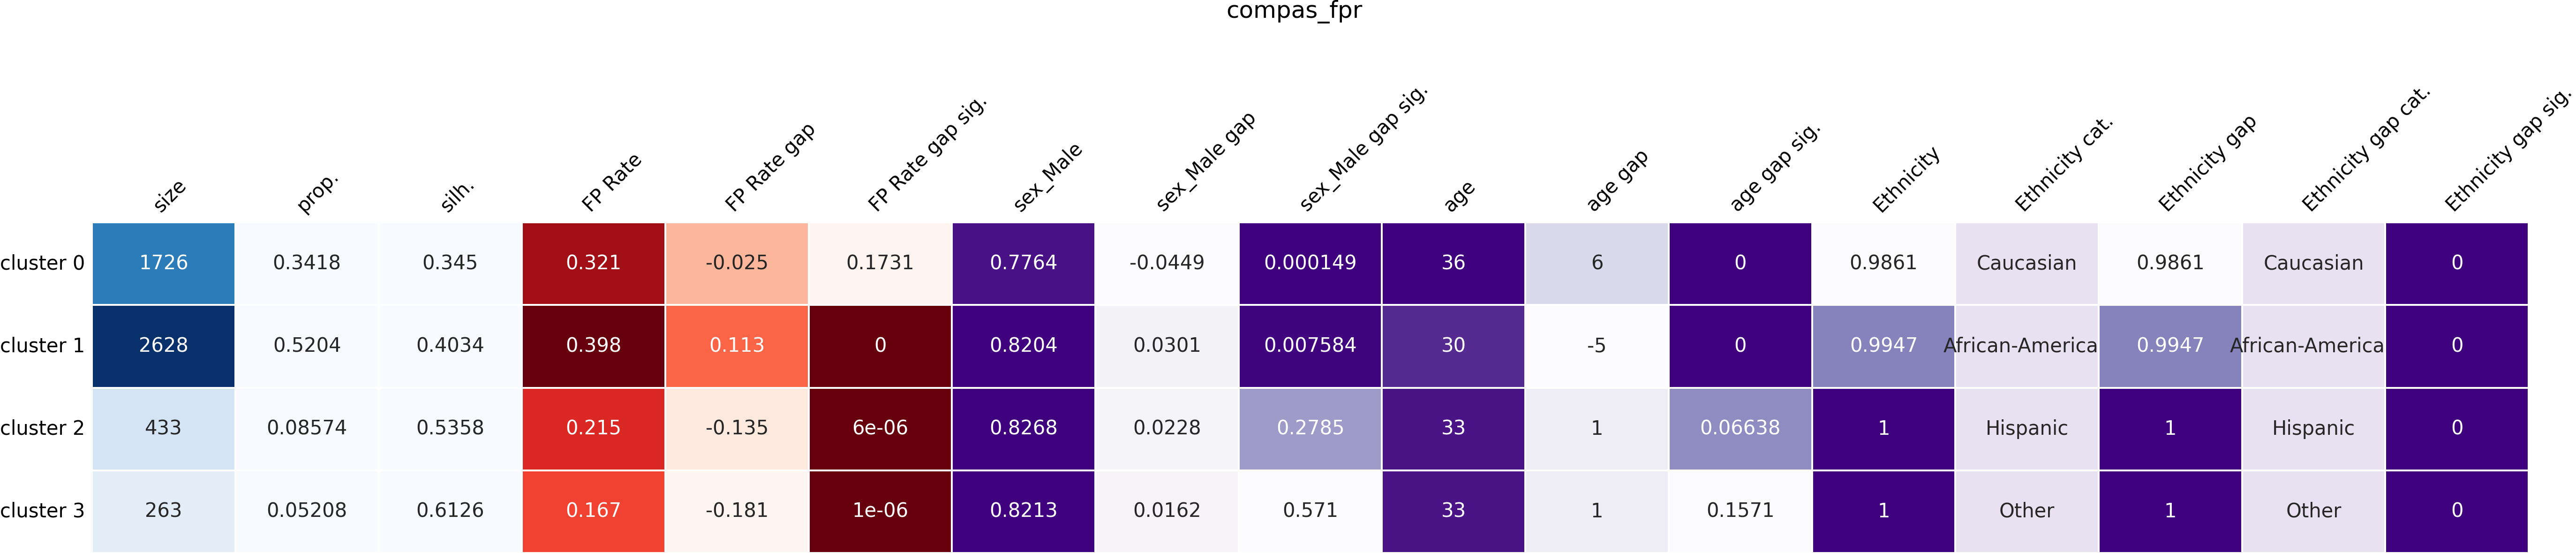

In [10]:
plot_cluster_recap_heatmap(recap.copy(), "compas_fpr", ".", error_label="FP Rate",
                           sensitive_labels={"race": "Ethnicity"})
Image("compas_fpr.png")

## Takeaway

The cluster with the highest FPR and a significant `FP Rate gap sig.` is where the model most over-predicts risk, and its `race` and `age` columns show which defendants land there.

Swap `"fpr"` for `"fnr"` to audit missed re-offenders instead. Pass `n_min` and `n_max` to `cluster` for silhouette-based k selection. The CLI `--experiment` mode runs every feature-group combination and writes an Overview table plus comparison heatmaps.